In [1]:
# loading the Libaries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
print(type(mnist))
print(mnist.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
x = mnist.data
y = mnist.target

print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


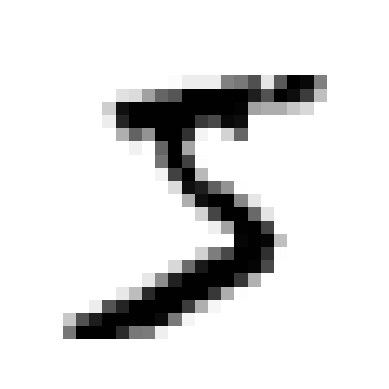

In [4]:
def plot_image(image):
    img = image.reshape(28, 28)
    plt.imshow(img, cmap='binary')
    plt.axis('off')

image = x[0]
plot_image(image)
plt.show()

In [5]:
y[0]

'5'

In [6]:
# training a binary classifier

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=10000, random_state=42)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(x_train, y_train_5)
sgd.predict([x[0]])

array([ True])

In [7]:
# testing Accuracy using cross validation

from sklearn.model_selection import cross_val_score

sgd_val_score = cross_val_score(sgd, x_train, y_train_5, cv=3, scoring='accuracy')
sgd_val_score

array([0.95945, 0.96735, 0.9657 ])

In [8]:
# testing Accuracy using dummy classifier
# it predicts the most frequent class in a dataset

from sklearn.dummy import DummyClassifier

dc = DummyClassifier()
dc.fit(x_train, y_train_5)
print(any(dc.predict(x_train)))
print()

dc_val_score = cross_val_score(dc, x_train, y_train_5, cv=3, scoring='accuracy')
dc_val_score

False



array([0.90985, 0.9098 , 0.9098 ])

In [9]:
# making a y_train prediction

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd, x_train, y_train_5, cv=3)
y_train_pred

array([False, False, False, ..., False, False, False], shape=(60000,))

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53487,  1102],
       [ 1654,  3757]])

In [11]:
# precision of the classifier is the accuracy of the positive predictions
# 

from sklearn.metrics import precision_score, recall_score

pred_score = precision_score(y_train_5, y_train_pred)
rec_score = recall_score(y_train_5, y_train_pred)

print('Precision Score:', pred_score)
print('Recall Score:', rec_score)

# Precision Score = 0.82 (≈82%) means: “When the model predicts a digit is 5, it’s correct about 82% of the time.”
#In other words, most of its positive predictions are right, but about 18% are false alarms (it said “5” when it wasn’t).

# Recall Score = 0.66 (≈66%) means: “Out of all the actual 5s in the dataset, the model correctly found about 66% of them.”
# So it misses around one‑third of the true 5s (false negatives).

Precision Score: 0.773204363037662
Recall Score: 0.6943263722047681


In [12]:
from sklearn.metrics import f1_score

f_score = f1_score(y_train_5, y_train_pred)
print('F1 Score:', f_score)

# F1 score of 0.73 means the classifier is reasonably good, but not excellent
# it’s cautious (good precision) but misses quite a few positives (lower recall). The F1 score captures that balance in one metric.

F1 Score: 0.7316455696202532


In [13]:
# Using decision_function()

y_score = sgd.decision_function([x[0]])
y_score

# a decision score of about 3203.89. which is positive means digit is 5

array([52.79936263])

In [14]:
# setting my own threshold
threshold=0
y_threshold_set = (y_score>threshold)
y_threshold_set 

array([ True])

In [15]:
threshold = 4000
y_threshold_set = (y_score>threshold)
y_threshold_set 

array([False])

In [16]:
# How to choose a Threshold

# Asking for a model confidence Scope
y_scores = cross_val_predict(sgd, x_train, y_train_5, cv=3, method='decision_function')
y_scores

array([-27077.8058879 , -11116.41466783, -21455.69735749, ...,
        -5882.59455922,  -4696.89708815,  -3333.22937012], shape=(60000,))

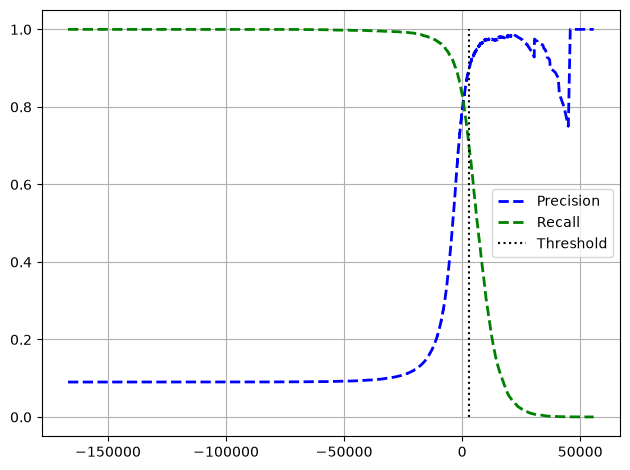

In [17]:
# computing values at different threshold
# he function adds a last precision of 0 and a last recall of 1, corresponding to an infinite threshold

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
plt.vlines(3000, 0, 1.0, 'k', 'dotted', label='Threshold')

plt.legend(loc="best")
plt.subplots_adjust(right=0.8)   # push plot left, leave space on right

plt.grid()
plt.tight_layout()
plt.show()

In [18]:
# argmax() returns the first index of the maximum value 

ind_90_pred = (precisions >= 0.90).argmax()
threshold_for_90 = thresholds[ind_90_pred]
threshold_for_90

np.float64(2979.7628868047273)

In [19]:
y_train_pred_90 = (y_scores >= threshold_for_90)
print(precision_score(y_train_5, y_train_pred_90))
print(recall_score(y_train_5, y_train_pred_90))

0.900119760479042
0.6945111809277398


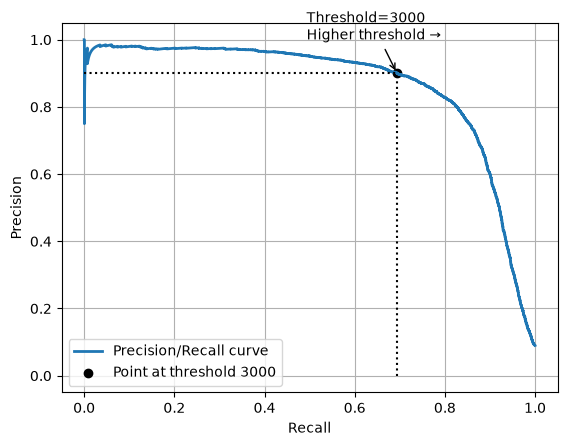

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Plot the Precision–Recall curve
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# --- Step 1: Pick threshold (e.g., 3000) ---
threshold = 3000

# --- Step 2: Find precision & recall at that threshold ---
# Locate the index where threshold is closest to 3000
idx = (thresholds >= threshold).argmax()
prec_at_thresh = precisions[idx]
rec_at_thresh = recalls[idx]

# --- Step 3: Plot the point ---
plt.scatter(rec_at_thresh, prec_at_thresh, color="black", label="Point at threshold 3000")

# --- Step 4: Add helper lines (optional) ---
plt.vlines(rec_at_thresh, 0, prec_at_thresh, colors="k", linestyles="dotted")
plt.hlines(prec_at_thresh, 0, rec_at_thresh, colors="k", linestyles="dotted")

# --- Step 5: Annotate with text (optional) ---
plt.annotate("Threshold=3000\nHigher threshold →",
             xy=(rec_at_thresh, prec_at_thresh),
             xytext=(rec_at_thresh-0.2, prec_at_thresh+0.1),
             arrowprops=dict(arrowstyle="->", color="black"))

# Labels & legend
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend(loc="lower left")
plt.show()


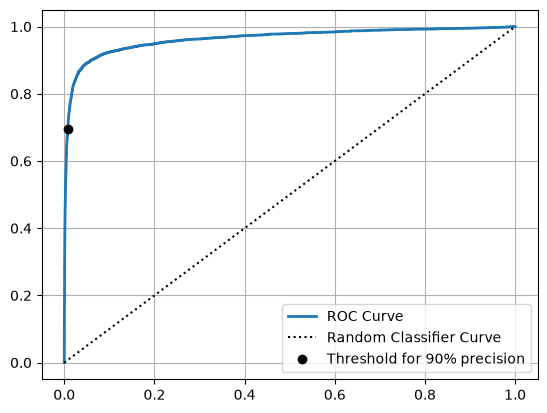

In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

ind_for_threshold_90 = (thresholds <= threshold_for_90).argmax()
fpr_90, tpr_90 = fpr[ind_for_threshold_90], tpr[ind_for_threshold_90]

plt.plot(fpr, tpr, label='ROC Curve', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label='Random Classifier Curve')
plt.plot([fpr_90], [tpr_90], 'ko', label='Threshold for 90% precision')

plt.grid()
plt.legend()
plt.show()


In [24]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_train_5, y_scores)
auc_score

# AUC = 0.9641 means your classifier has a 96.41% chance of ranking a random “5” higher than a random “non‑5”.

0.9641187646958254

In [26]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42)
y_forest_pred = cross_val_predict(forest, x_train, y_train_5, cv=3, method='predict_proba')
y_forest_pred

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [1.  , 0.  ],
       [0.87, 0.13],
       [0.84, 0.16]], shape=(60000, 2))

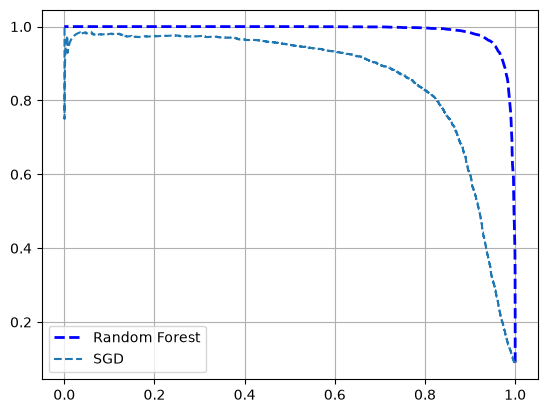

In [28]:
# The second column contains the estimated probabilities for the positive class

y_scores_forest = y_forest_pred[:, 1]
precision_forest, recall_forest, threshold_forest = precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recall_forest, precision_forest, 'b--', label='Random Forest', linewidth=2)
plt.plot(recalls, precisions, '--', label='SGD')
plt.legend()
plt.grid()
plt.show()

# As you can see in Figure 3-8, the RandomForestClassifier’s PR curve looks much better than the SGDClassifier’s: it comes much closer to the
# top-right corner. Its F score and ROC AUC score are also significantly better